In [ ]:
import cv2

cap = cv2.VideoCapture("IMG_0517__1_.MOV")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps
cap.release()

print(f"FPS: {fps}")
print(f"Resolution: {width}x{height}")
print(f"Duration: {duration:.1f} seconds")
print(f"Total frames: {total_frames}")

FPS: 30.0
Resolution: 854x480
Duration: 306.2 seconds
Total frames: 9187


In [1]:
from google.colab import files
uploaded = files.upload()

Saving 4K Road traffic video for object detection and tracking - free download now!.mp4 to 4K Road traffic video for object detection and tracking - free download now!.mp4


In [3]:
import os
os.rename("4K Road traffic video for object detection and tracking - free download now!.mp4", "IMG_0517__1_.MOV")
print("Renamed successfully")

Renamed successfully


In [4]:
import cv2

cap = cv2.VideoCapture("IMG_0517__1_.MOV")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps
cap.release()

print(f"FPS: {fps}")
print(f"Resolution: {width}x{height}")
print(f"Duration: {duration:.1f} seconds")
print(f"Total frames: {total_frames}")

FPS: 30.0
Resolution: 854x480
Duration: 306.2 seconds
Total frames: 9187


In [5]:
!pip install ultralytics opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.1 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO
import cv2
print("Imports successful")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports successful


In [7]:
# Vehicle class IDs in COCO dataset
# 2=car, 3=motorcycle, 5=bus, 7=truck
VEHICLE_CLASSES = [2, 3, 5, 7]

# Load model
model = YOLO("yolov8n.pt")

# Open video
cap = cv2.VideoCapture("IMG_0517__1_.MOV")
fps = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Output writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("task1_output.mp4", fourcc, fps, (width, height))

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, verbose=False)[0]

    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])

        if cls_id not in VEHICLE_CLASSES or conf < 0.4:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        label = f"{model.names[cls_id]} {conf:.2f}"

        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, label, (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    out.write(frame)
    frame_count += 1

    if frame_count % 500 == 0:
        print(f"Processed {frame_count}/{9187} frames...")

cap.release()
out.release()
print(f"Done! Processed {frame_count} frames → task1_output.mp4")

Processed 500/9187 frames...
Processed 1000/9187 frames...
Processed 1500/9187 frames...
Processed 2000/9187 frames...
Processed 2500/9187 frames...
Processed 3000/9187 frames...
Processed 3500/9187 frames...
Processed 4000/9187 frames...
Processed 4500/9187 frames...
Processed 5000/9187 frames...
Processed 5500/9187 frames...
Processed 6000/9187 frames...
Processed 6500/9187 frames...
Processed 7000/9187 frames...
Processed 7500/9187 frames...
Processed 8000/9187 frames...
Processed 8500/9187 frames...
Processed 9000/9187 frames...
Done! Processed 9184 frames → task1_output.mp4


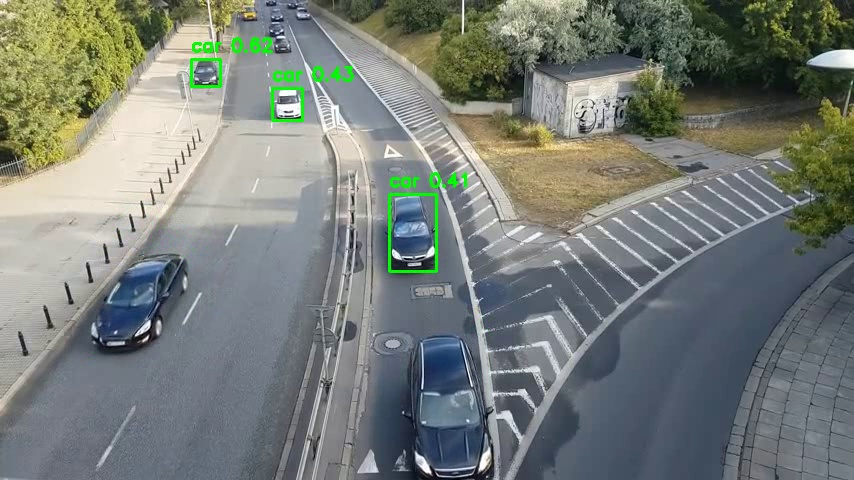

In [9]:
from IPython.display import display, Image

cap = cv2.VideoCapture("task1_output.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()
cap.release()

cv2.imwrite("preview.jpg", frame)
display(Image("preview.jpg"))

In [10]:
from google.colab import files
files.download("task1_output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
!pip install ultralytics opencv-python-headless

In [13]:
from ultralytics import YOLO
import cv2
print("Ready")

Ready


In [15]:
VEHICLE_CLASSES = [2, 3, 5, 7]
CLASS_NAMES = {2: "Car", 3: "Motorcycle", 5: "Bus", 7: "Truck"}

model = YOLO("yolov8n.pt")

cap = cv2.VideoCapture("IMG_0517__1_.MOV")
fps = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("task2_output.mp4", fourcc, fps, (width, height))

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Use YOLO's built-in tracker (BoT-SORT)
    results = model.track(
        frame,
        persist=True,        # maintains ID across frames
        tracker="botsort.yaml",
        verbose=False
    )[0]

    if results.boxes.id is not None:
        for box, track_id, cls_id, conf in zip(
            results.boxes.xyxy,
            results.boxes.id,
            results.boxes.cls,
            results.boxes.conf
        ):
            cls_id = int(cls_id)
            conf   = float(conf)
            track_id = int(track_id)

            if cls_id not in VEHICLE_CLASSES or conf < 0.4:
                continue

            x1, y1, x2, y2 = map(int, box)
            vehicle_type = CLASS_NAMES.get(cls_id, "Vehicle")
            label = f"{vehicle_type} {track_id}"

            # Draw box
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 200, 255), 2)

            # Draw label background
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame, (x1, y1 - th - 10), (x1 + tw + 4, y1), (0, 200, 255), -1)

            # Draw label text
            cv2.putText(frame, label, (x1 + 2, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    out.write(frame)
    frame_count += 1

    if frame_count % 500 == 0:
        print(f"Processed {frame_count}/9187 frames...")

cap.release()
out.release()
print(f"Done!")

Processed 500/9187 frames...
Processed 1000/9187 frames...
Processed 1500/9187 frames...
Processed 2000/9187 frames...
Processed 2500/9187 frames...
Processed 3000/9187 frames...
Processed 3500/9187 frames...
Processed 4000/9187 frames...
Processed 4500/9187 frames...
Processed 5000/9187 frames...
Processed 5500/9187 frames...
Processed 6000/9187 frames...
Processed 6500/9187 frames...
Processed 7000/9187 frames...
Processed 7500/9187 frames...
Processed 8000/9187 frames...
Processed 8500/9187 frames...
Processed 9000/9187 frames...
Done!


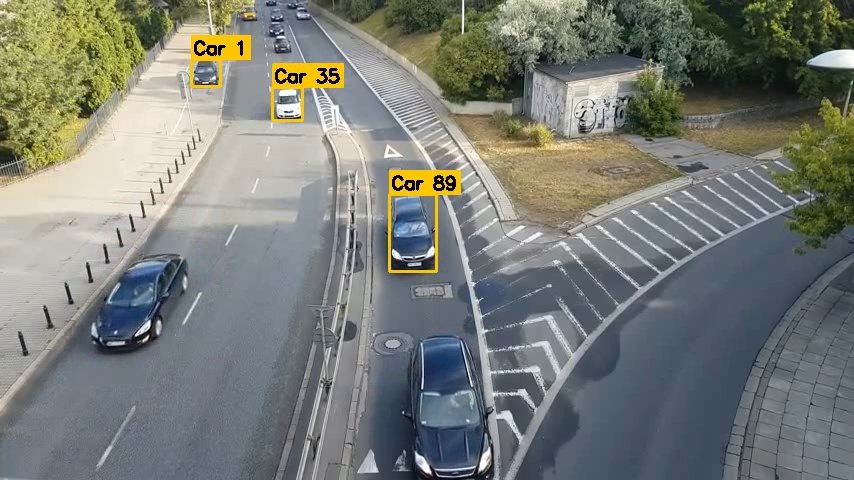

In [16]:
from IPython.display import display, Image

cap = cv2.VideoCapture("task2_output.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()
cap.release()

cv2.imwrite("preview2.jpg", frame)
display(Image("preview2.jpg"))

In [17]:
from google.colab import files
files.download("task2_output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from google.colab import files
files.download("task2_output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

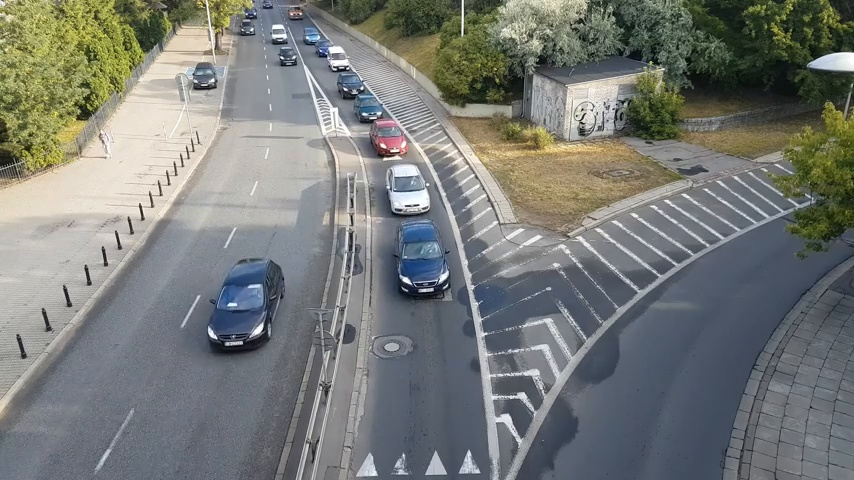

In [19]:
from IPython.display import display, Image
import cv2

cap = cv2.VideoCapture("IMG_0517__1_.MOV")
cap.set(cv2.CAP_PROP_POS_FRAMES, 4500)  # middle of video
ret, frame = cap.read()
cap.release()

cv2.imwrite("road_check.jpg", frame)
display(Image("road_check.jpg"))

In [20]:
from ultralytics import YOLO
import cv2
print("Ready")

Ready


In [21]:
VEHICLE_CLASSES = [2, 3, 5, 7]
CLASS_NAMES = {2: "Car", 3: "Motorcycle", 5: "Bus", 7: "Truck"}

# ── CONFIGURATION ─────────────────────────────────────────
LINE_1_Y = 580
LINE_2_Y = 780
PIXEL_TO_METER = 0.05
LINE_DISTANCE_M = abs(LINE_2_Y - LINE_1_Y) * PIXEL_TO_METER  # ~10.0m
FPS = 30.0
SPEED_LIMIT = 120  # km/h — vehicles above this are flagged red

# ── MODEL & VIDEO SETUP ───────────────────────────────────
model = YOLO("yolov8n.pt")

cap = cv2.VideoCapture("IMG_0517__1_.MOV")
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("task3_output.mp4", fourcc, FPS, (width, height))

# ── TRACKING STATE ────────────────────────────────────────
vehicle_data = {}   # {track_id: {line1_frame, line2_frame, speed, type}}
total_detected = set()
total_speeding = set()

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(
        frame,
        persist=True,
        tracker="botsort.yaml",
        verbose=False
    )[0]

    # ── REFERENCE LINES ───────────────────────────────────
    cv2.line(frame, (0, LINE_1_Y), (width, LINE_1_Y), (255, 255, 0), 2)
    cv2.line(frame, (0, LINE_2_Y), (width, LINE_2_Y), (0, 255, 255), 2)
    cv2.putText(frame, "Line 1", (10, LINE_1_Y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2)
    cv2.putText(frame, "Line 2", (10, LINE_2_Y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 255), 2)

    if results.boxes.id is not None:
        for box, track_id, cls_id, conf in zip(
            results.boxes.xyxy,
            results.boxes.id,
            results.boxes.cls,
            results.boxes.conf
        ):
            cls_id   = int(cls_id)
            conf     = float(conf)
            track_id = int(track_id)

            if cls_id not in VEHICLE_CLASSES or conf < 0.4:
                continue

            total_detected.add(track_id)

            x1, y1, x2, y2 = map(int, box)
            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2

            if track_id not in vehicle_data:
                vehicle_data[track_id] = {
                    "line1_frame": None,
                    "line2_frame": None,
                    "speed": None,
                    "type": CLASS_NAMES.get(cls_id, "Vehicle")
                }

            vd = vehicle_data[track_id]

            # Line crossing detection
            if abs(cy - LINE_1_Y) < 10 and vd["line1_frame"] is None:
                vd["line1_frame"] = frame_count
            if abs(cy - LINE_2_Y) < 10 and vd["line2_frame"] is None:
                vd["line2_frame"] = frame_count

            # Speed calculation
            if (vd["line1_frame"] is not None and
                vd["line2_frame"] is not None and
                vd["speed"] is None):
                frames_elapsed = abs(vd["line2_frame"] - vd["line1_frame"])
                if frames_elapsed > 0:
                    time_elapsed = frames_elapsed / FPS
                    speed_ms  = LINE_DISTANCE_M / time_elapsed
                    speed_kmh = speed_ms * 3.6
                    vd["speed"] = round(speed_kmh, 1)
                    if vd["speed"] > SPEED_LIMIT:
                        total_speeding.add(track_id)

            # ── COLOUR LOGIC ──────────────────────────────
            if vd["speed"] is None:
                color = (0, 200, 255)      # yellow-orange: no speed yet
            elif vd["speed"] > SPEED_LIMIT:
                color = (0, 0, 255)        # RED: speeding!
            else:
                color = (0, 255, 100)      # green: within limit

            # ── VEHICLE LABEL ─────────────────────────────
            speed_text = f"{vd['speed']} km/h" if vd["speed"] else "..."
            alert_tag  = " ⚠ SPEEDING" if vd["speed"] and vd["speed"] > SPEED_LIMIT else ""
            label = f"{vd['type']} {track_id} | {speed_text}{alert_tag}"

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
            cv2.rectangle(frame, (x1, y1 - th - 10), (x1 + tw + 4, y1), color, -1)
            cv2.putText(frame, label, (x1 + 2, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2)
            cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)

    # ── DASHBOARD UI OVERLAY ──────────────────────────────
    # Semi-transparent dark panel top-right
    panel_x, panel_y = width - 340, 10
    panel_w, panel_h = 325, 130
    overlay = frame.copy()
    cv2.rectangle(overlay, (panel_x, panel_y),
                  (panel_x + panel_w, panel_y + panel_h), (20, 20, 20), -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

    # Panel border
    cv2.rectangle(frame, (panel_x, panel_y),
                  (panel_x + panel_w, panel_y + panel_h), (200, 200, 200), 1)

    # Title
    cv2.putText(frame, "SPEED MONITOR", (panel_x + 10, panel_y + 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

    # Stats
    speeding_now = sum(1 for tid, vd in vehicle_data.items()
                       if vd["speed"] and vd["speed"] > SPEED_LIMIT
                       and results.boxes.id is not None
                       and tid in [int(i) for i in results.boxes.id])

    cv2.putText(frame, f"Vehicles Detected : {len(total_detected)}",
                (panel_x + 10, panel_y + 52),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52, (0, 255, 180), 1)
    cv2.putText(frame, f"Speed Limit       : {SPEED_LIMIT} km/h",
                (panel_x + 10, panel_y + 75),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 255), 1)
    cv2.putText(frame, f"Speeding (total)  : {len(total_speeding)}",
                (panel_x + 10, panel_y + 98),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52,
                (0, 0, 255) if total_speeding else (0, 255, 180), 1)
    cv2.putText(frame, f"Frame             : {frame_count}/611",
                (panel_x + 10, panel_y + 121),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52, (180, 180, 180), 1)

    out.write(frame)
    frame_count += 1

    if frame_count % 100 == 0:
        print(f"Processed {frame_count}/611 frames...")

cap.release()
out.release()
print(f"Done! Detected {len(total_detected)} vehicles, {len(total_speeding)} speeding.")


Processed 500/9187 frames...
Processed 1000/9187 frames...
Processed 1500/9187 frames...
Processed 2000/9187 frames...
Processed 2500/9187 frames...
Processed 3000/9187 frames...
Processed 3500/9187 frames...
Processed 4000/9187 frames...
Processed 4500/9187 frames...
Processed 5000/9187 frames...
Processed 5500/9187 frames...
Processed 6000/9187 frames...
Processed 6500/9187 frames...
Processed 7000/9187 frames...
Processed 7500/9187 frames...
Processed 8000/9187 frames...
Processed 8500/9187 frames...
Processed 9000/9187 frames...
Done.. task3_output.mp4 ready


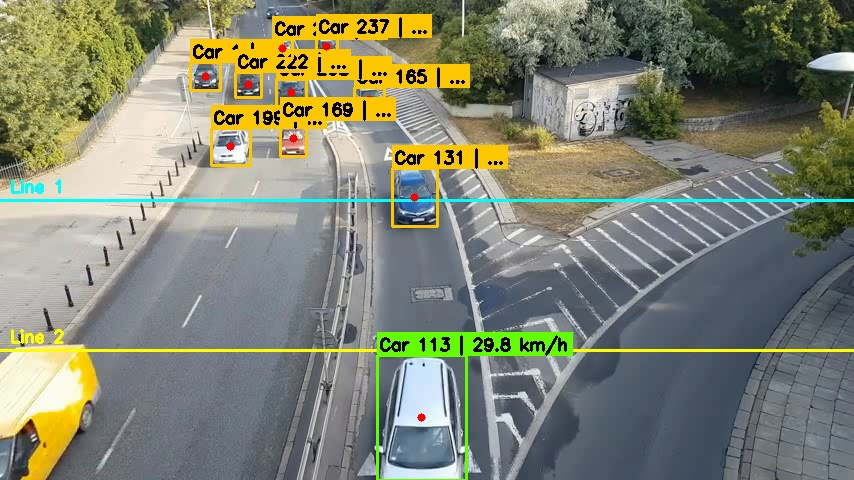

In [22]:
from IPython.display import display, Image

cap = cv2.VideoCapture("task3_output.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, 300)
ret, frame = cap.read()
cap.release()

cv2.imwrite("preview3.jpg", frame)
display(Image("preview3.jpg"))

In [24]:
from google.colab import files
files.download("task3_output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>